In [1]:
import numpy as np
import os
import pandas as pd
import xarray as xr
from glob import glob
import matplotlib.pyplot as plt
import itertools as it
from scipy.stats import linregress
from matplotlib.cm import get_cmap
from utils.constants import chamber_levels_complete
import matplotlib.ticker as ticker
import itertools as it
from matplotlib import rcParams
from matplotlib.colors import BoundaryNorm
from utils.analysis import uq_get_obs, uq_get_sim
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter

rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

prefix_list = ['20231116', 'UQ_20231118', 'UQ_20240107', 'UQ_20240112']
ens_member = ['g03066', 'g00866']

pft_names = ['Spruce', 'Tamarack'] # , 'Shrub']
pft_list = [2, 3] # , 11]

chamber = 'TAMB'

hol_add = 17

In [2]:
sminn_uptake = pd.DataFrame(np.nan, index = range(1,366), 
                            columns = pd.MultiIndex.from_product([prefix_list, pft_names]))
for prefix, ens_id in zip(prefix_list, ens_member):
    flist = [os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ', 
                          f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', ens_id, chamber,
                          f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC.elm.h2.{year}-01-01-00000.nc')
             for year in range(2015, 2022)]

    hr = xr.open_mfdataset(flist)
    for pft,pftn in zip(pft_list, pft_names):
        temp = (hr['SMINN_TO_NPOOL'][:,pft].values*0.64 + \
                hr['SMINN_TO_NPOOL'][:,pft+hol_add].values*0.36) * 86400 # gN m-2 day-1
        sminn_uptake.loc[:, (prefix, pftn)] = np.mean(temp.reshape(-1,365), axis = 0)
    hr.close()

In [44]:
frootc = pd.DataFrame(np.nan, index = range(1,366), 
                            columns = pd.MultiIndex.from_product([prefix_list, pft_names]))
for prefix, ens_id in zip(prefix_list, ens_member):
    flist = [os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ', 
                          f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', ens_id, chamber,
                          f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC.elm.h2.{year}-01-01-00000.nc')
             for year in range(2015, 2022)]

    hr = xr.open_mfdataset(flist)
    for pft,pftn in zip(pft_list, pft_names):
        temp = (hr['FROOTC'][:,pft].values*0.64 + \
                hr['FROOTC'][:,pft+hol_add].values*0.36) # gC m-2
        frootc.loc[:, (prefix, pftn)] = np.mean(temp.reshape(-1,365), axis = 0)
    hr.close()

leafc = pd.DataFrame(np.nan, index = range(1,366), 
                            columns = pd.MultiIndex.from_product([prefix_list, pft_names]))
for prefix, ens_id in zip(prefix_list, ens_member):
    flist = [os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ', 
                          f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', ens_id, chamber,
                          f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC.elm.h2.{year}-01-01-00000.nc')
             for year in range(2015, 2022)]

    hr = xr.open_mfdataset(flist)
    for pft,pftn in zip(pft_list, pft_names):
        temp = (hr['LEAFC'][:,pft].values*0.64 + \
                hr['LEAFC'][:,pft+hol_add].values*0.36) # gC m-2
        leafc.loc[:, (prefix, pftn)] = np.mean(temp.reshape(-1,365), axis = 0)
    hr.close()

livestemc = pd.DataFrame(np.nan, index = range(1,366), 
                            columns = pd.MultiIndex.from_product([prefix_list, pft_names]))
for prefix, ens_id in zip(prefix_list, ens_member):
    flist = [os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ', 
                          f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', ens_id, chamber,
                          f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC.elm.h2.{year}-01-01-00000.nc')
             for year in range(2015, 2022)]

    hr = xr.open_mfdataset(flist)
    for pft,pftn in zip(pft_list, pft_names):
        temp = (hr['LIVESTEMC'][:,pft].values*0.64 + \
                hr['LIVESTEMC'][:,pft+hol_add].values*0.36) # gC m-2
        livestemc.loc[:, (prefix, pftn)] = np.mean(temp.reshape(-1,365), axis = 0)
    hr.close()

In [17]:
sminn = pd.DataFrame(np.nan, index = range(1,366), columns = prefix_list)
for prefix, ens_id in zip(prefix_list, ens_member):
    flist = [os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ', 
                          f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', ens_id, chamber,
                          f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC.elm.h1.{year}-01-01-00000.nc')
             for year in range(2015, 2022)]

    hr = xr.open_mfdataset(flist)
    temp = hr['SMINN'][:,0].values*0.64 + hr['SMINN'][:,1].values*0.36 # gN m-2
    sminn.loc[:, prefix] = np.mean(temp.reshape(-1,365), axis = 0)
    hr.close()


rh = pd.DataFrame(np.nan, index = range(1,366), columns = prefix_list)
for prefix, ens_id in zip(prefix_list, ens_member):
    flist = [os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ', 
                          f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', ens_id, chamber,
                          f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC.elm.h1.{year}-01-01-00000.nc')
             for year in range(2015, 2022)]

    hr = xr.open_mfdataset(flist)
    temp = hr['HR'][:,0].values*0.64 + hr['HR'][:,1].values*0.36 # gC m-2 day-1
    rh.loc[:, prefix] = np.mean(temp.reshape(-1,365), axis = 0) * 86400
    hr.close()

Text(0.5, 1.0, 'Simulation result at SPRUCE TAMB chamber')

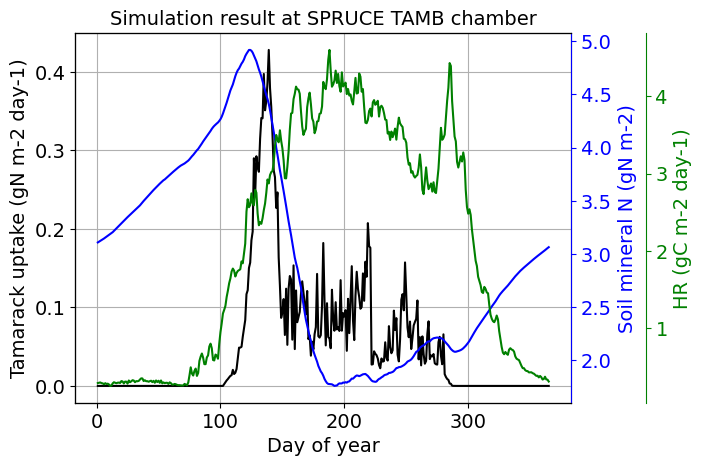

In [38]:
prefix = 'UQ_20240112'

fig, ax = plt.subplots()

ax.plot(sminn_uptake.index, sminn_uptake.loc[:,(prefix, 'Tamarack')], '-k', zorder = 3)
ax.set_ylabel('Tamarack uptake (gN m-2 day-1)')

ax2 = ax.twinx()
ax2.spines["right"].set_color("b")   # axis line
ax2.tick_params(axis="y", colors="b")
ax2.plot(sminn.index, sminn.loc[:,prefix], '-b')
ax2.set_ylabel('Soil mineral N (gN m-2)', color = 'b')

ax3 = ax.twinx()
ax3.spines["right"].set_position(("axes", 1.15))  # 1.0 is ax_right; 1.15 is 15 % farther out
ax3.spines["right"].set_color("g")   # axis line
ax3.tick_params(axis="y", colors="g")
ax3.plot(rh.index, rh.loc[:,prefix], '-g')
ax3.set_ylabel('HR (gC m-2 day-1)', color = 'g')

ax.set_xlabel('Day of year')
ax.grid(True)

ax.set_title('Simulation result at SPRUCE TAMB chamber')

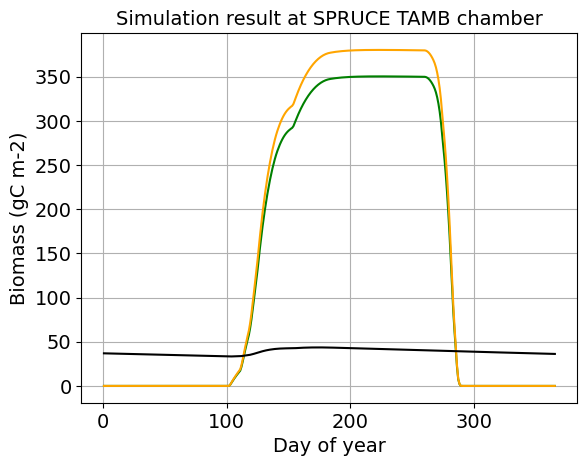

In [47]:
prefix = 'UQ_20240112'

fig, ax = plt.subplots()

ax.plot(leafc.index, leafc.loc[:,(prefix, 'Tamarack')], '-g', zorder = 3, label = 'leaf')

ax.plot(frootc.index, frootc.loc[:,(prefix, 'Tamarack')], '-', color = 'orange', 
        zorder = 3, label = 'fine root')

ax.plot(livestemc.index, livestemc.loc[:,(prefix, 'Tamarack')], '-k', zorder = 3, 
        label = 'livestem')

ax.set_ylabel('Biomass (gC m-2)')

ax.set_title('Simulation result at SPRUCE TAMB chamber')

ax.set_xlabel('Day of year')
ax.grid(True)